<a href="https://colab.research.google.com/github/vijipandian/project/blob/main/The_Movie_Dataset(1950_2025).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("/content/tmdb_movies.csv")
data.head(3)

,id,title,genre,release_date,release_year,budget,revenue,runtime,vote_average,vote_count,production_country
0,1,Movie Title 1,"Science Fiction, Comedy, Horror",1957-01-01,1957,36972721,1.306928e+08,123,4.496790,9221,Germany
1,2,Movie Title 2,"Documentary, Romance",1999-01-01,1999,96359319,2.947975e+08,146,5.803306,4592,China
2,3,Movie Title 3,"Science Fiction, Action",1941-01-01,1941,135172742,1.048409e+08,168,2.710639,7146,Japan


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  100 non-null    int64  
 1   title               100 non-null    object 
 2   genre               100 non-null    object 
 3   release_date        100 non-null    object 
 4   release_year        100 non-null    int64  
 5   budget              100 non-null    int64  
 6   revenue             100 non-null    float64
 7   runtime             100 non-null    int64  
 8   vote_average        100 non-null    float64
 9   vote_count          100 non-null    int64  
 10  production_country  100 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 8.7+ KB


In [4]:
data.duplicated().sum()

np.int64(0)

In [5]:
data.isnull().sum()

,0
id,0
title,0
genre,0
release_date,0
release_year,0
budget,0
revenue,0
runtime,0
vote_average,0
vote_count,0


In [6]:
data.nunique()

,0
id,100
title,100
genre,69
release_date,59
release_year,59
budget,100
revenue,100
runtime,59
vote_average,100
vote_count,99


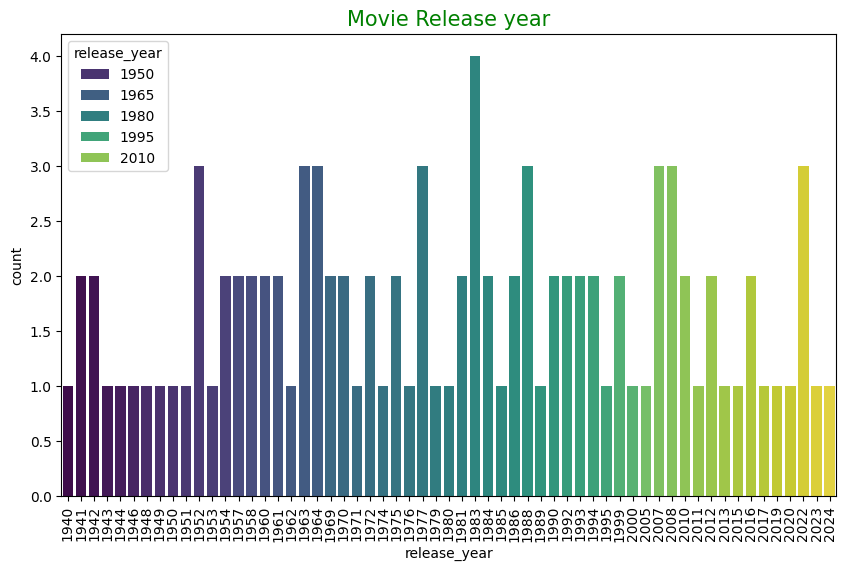

In [7]:
plt.figure(figsize=(10,6))
sns.countplot(x="release_year",data=data,palette="viridis",hue="release_year")
plt.xticks(rotation=90)
plt.title("Movie Release year",fontsize=15,color="green")
plt.show()

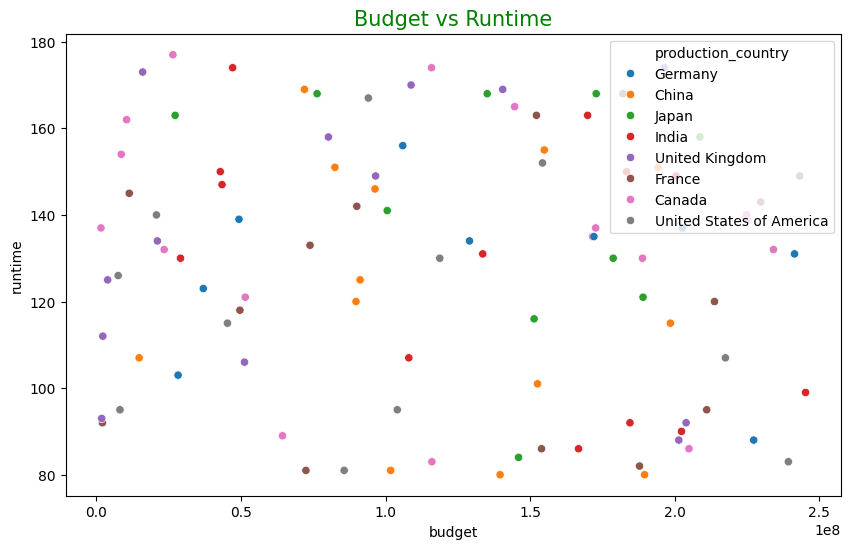

In [8]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="budget",y="runtime",hue="production_country",data=data)
plt.xlabel("budget")
plt.ylabel("runtime")
plt.title("Budget vs Runtime",fontsize=15,color="green")
plt.show()

In [9]:
top=data['genre'].value_counts().head(5)
print(top)

genre
Adventure      8
Horror         5
Action         3
Documentary    3
Drama          3
Name: count, dtype: int64


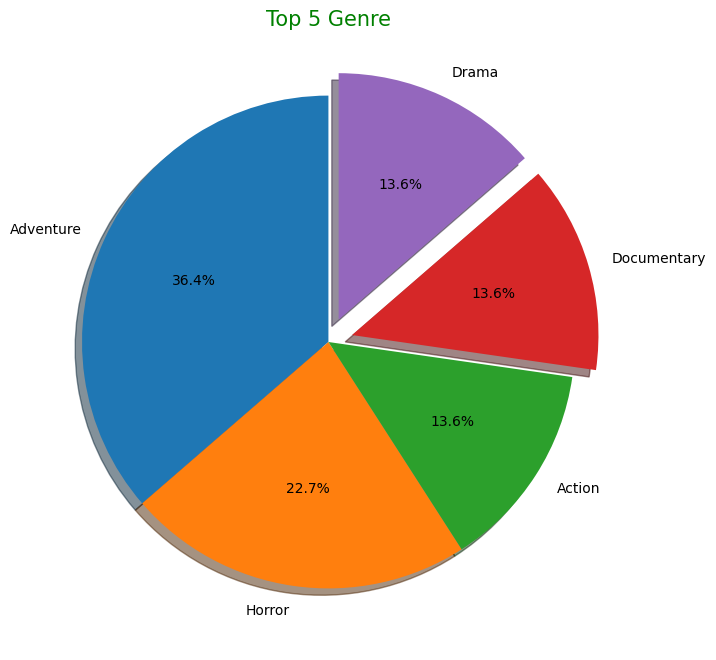

In [10]:
plt.figure(figsize=(10,8))
plt.pie(
    top.values,
    labels=["Adventure","Horror","Action","Documentary","Drama"],
    autopct="%1.1f%%",
    explode=(0,0,0,0.1,0.1),
    shadow=True,
    startangle=90)

plt.title("Top 5 Genre",fontsize=15,color="green")
plt.show()

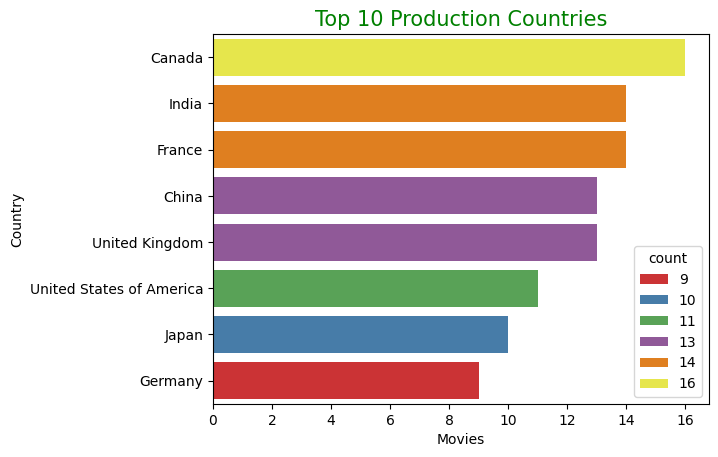

In [11]:
country=data['production_country'].value_counts().head(10)

sns.barplot(
    x=country.values,
    y=country.index,
    palette="Set1",
    hue=country
)
plt.title("Top 10 Production Countries",fontsize=15,color="green")
plt.xlabel("Movies")
plt.ylabel("Country")
plt.show()

In [12]:
vote=data.groupby("genre")["vote_count"].sum()
print(vote)

genre
Action                                25476
Action, Adventure                      7325
Action, Adventure, Horror              2198
Action, Adventure, Science Fiction     9990
Action, Comedy, Documentary            4201
                                      ...  
Science Fiction, Comedy, Horror        9221
Science Fiction, Comedy, Romance       1966
Science Fiction, Drama                 9622
Science Fiction, Horror                1601
Science Fiction, Horror, Adventure     4146
Name: vote_count, Length: 69, dtype: int64


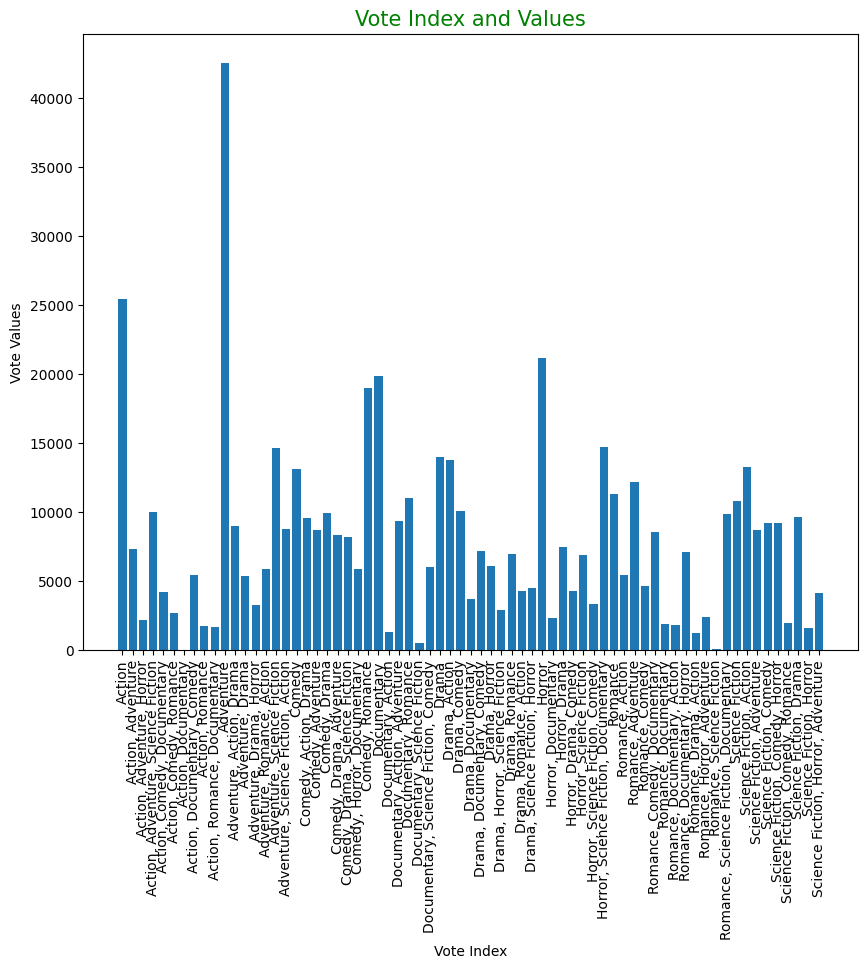

In [13]:
plt.figure(figsize=(10,8))
plt.bar(vote.index,vote.values)
plt.xlabel("Vote Index")
plt.ylabel("Vote Values")
plt.title("Vote Index and Values",fontsize=15,color="green")
plt.xticks(rotation=90)
plt.show()

In [25]:
data['genre']=data['genre'].fillna(data['genre'].mode()[0])

In [26]:
data['runtime']=data['runtime'].fillna(data['runtime'].median())

In [27]:
data['vote_count']=data['vote_count'].fillna(data['vote_count'].median())

In [28]:
data['production_country']=data['production_country'].fillna(data['production_country'].mode()[0])

In [18]:
data.isna().sum()

,0
id,0
title,0
genre,0
release_date,0
release_year,0
budget,0
revenue,0
runtime,0
vote_average,0
vote_count,0


**ML**

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [50]:
x=data[
    [
        'budget',
        'runtime',
        'vote_average',
        'vote_count',
        'genre',
        'production_country'
    ]
]

y=data['revenue']

In [51]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [52]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(80, 6)
(20, 6)
(80,)
(20,)


In [53]:
lab=LabelEncoder()
data['genre']=lab.fit_transform(data['genre'])

la=LabelEncoder()
data['production_country']=la.fit_transform(data['production_country'])

In [54]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [55]:
y_pred=model.predict(x_test)

In [58]:
print("R2_Score:",r2_score(y_test,y_pred))

R2_Score: 0.5154797366519939


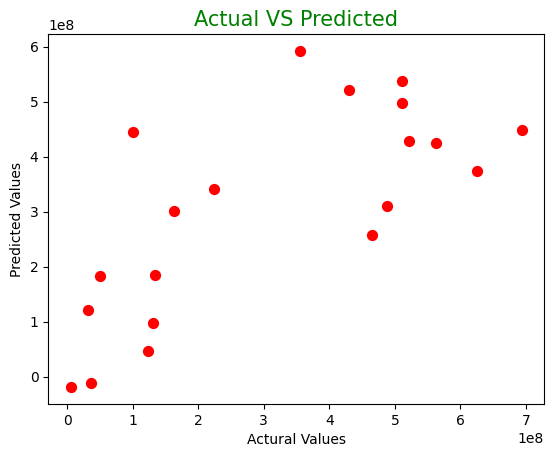

In [74]:
plt.scatter(y_test,y_pred,color="red",s=50)
plt.xlabel("Actural Values")
plt.ylabel("Predicted Values")
plt.title("Actual VS Predicted",fontsize=15,color="green")
plt.show()